Please upload an image to start.


Saving myphoto.jpg to myphoto.jpg

========== MAIN MENU ==========
1. Image Filters
2. Transformations (Geometric/Affine)
0. Exit
Enter selection: 1

--- FILTER MENU ---
1. Point Filter (Scale UP x5)
2. Point Filter (Scale DOWN x1/9)
3. Mean Filter (3x3)
4. Median Filter (5x5)
0. Back to Main Menu
Select Filter: 1


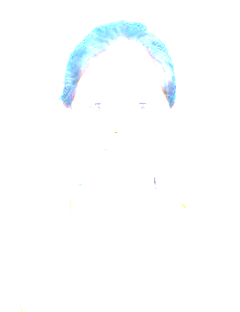


--- FILTER MENU ---
1. Point Filter (Scale UP x5)
2. Point Filter (Scale DOWN x1/9)
3. Mean Filter (3x3)
4. Median Filter (5x5)
0. Back to Main Menu


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from google.colab import files
from google.colab.patches import cv2_imshow

# ==============================
# 1. IMAGE FILTERS CLASS
# ==============================
class ImageFilters:
    def __init__(self, path):
        self.image = cv2.imread(path)
        if self.image is None:
            print("Error: Could not load image for filtering.")

    def point_filter(self, scale=1.0):
        if self.image is None: return None
        float_img = self.image.astype(np.float32)
        res = float_img * scale
        return np.clip(res, 0, 255).astype(np.uint8)

    def mean_filter(self, k_size=3):
        return cv2.blur(self.image, (k_size, k_size))

    def median_filter(self, k_size=5):
        return cv2.medianBlur(self.image, k_size)

    def run_menu(self):
        while True:
            print("\n--- FILTER MENU ---")
            print("1. Point Filter (Scale UP x5)")
            print("2. Point Filter (Scale DOWN x1/9)")
            print("3. Mean Filter (3x3)")
            print("4. Median Filter (5x5)")
            print("0. Back to Main Menu")

            choice = input("Select Filter: ")
            if choice == '0': break

            if choice == '1':
                cv2_imshow(self.point_filter(scale=5.0))
            elif choice == '2':
                cv2_imshow(self.point_filter(scale=1/9))
            elif choice == '3':
                cv2_imshow(self.mean_filter())
            elif choice == '4':
                cv2_imshow(self.median_filter())

# ==============================
# 2. GEOMETRIC TRANSFORMER CLASS
# ==============================
class GeometricTransformer:
    def __init__(self, image_path):
        self.img_pil = Image.open(image_path)

    def translate(self, tx=50, ty=30):
        width, height = self.img_pil.size
        new_img = Image.new("RGB",(width+int(abs(tx)*2),height+int(abs(ty)*2)),(255,255,255))
        new_img.paste(self.img_pil,(int(abs(tx)),int(abs(ty))))
        return new_img.crop((tx,ty,tx+width,ty+height))

    def rotate(self, angle=45):
        return self.img_pil.rotate(angle, expand=True)

    def scale(self, sx=1.5, sy=0.8):
        w,h = self.img_pil.size
        return self.img_pil.resize((int(w*sx),int(h*sy)))

    def shear(self, shx=0.3, shy=0.2):
        img_array = np.array(self.img_pil)
        h,w = img_array.shape[:2]
        X,Y = np.meshgrid(np.arange(w),np.arange(h))
        map_x = np.clip(X + shx*Y,0,w-1).astype(int)
        map_y = np.clip(Y + shy*X,0,h-1).astype(int)
        sheared = img_array[map_y,map_x]
        return Image.fromarray(sheared)

    def interactive_menu(self):
        while True:
            print("\n--- GEOMETRIC TRANSFORMATIONS ---")
            print("1 Translation\n2 Rotation\n3 Scaling\n4 Shear\n0 Back")
            choice = input("Choice: ")
            if choice == '0': break

            if choice == '1':
                tx, ty = float(input("X: ")), float(input("Y: "))
                res = self.translate(tx, ty)
            elif choice == '2':
                res = self.rotate(float(input("Angle: ")))
            elif choice == '3':
                res = self.scale(float(input("SX: ")), float(input("SY: ")))
            elif choice == '4':
                res = self.shear(float(input("SHX: ")), float(input("SHY: ")))
            else: continue

            plt.imshow(res); plt.axis("off"); plt.show()

# ==============================
# 3. AFFINE CLASS
# ==============================
class FlexibleAffine:
    def __init__(self, image_path):
        self.image_path = image_path
        self.matrix = np.eye(3)
        self.img = cv2.imread(image_path, 0)
        self.rows, self.cols = self.img.shape

    def add_rotation(self, angle):
        center = (self.cols//2, self.rows//2)
        rot = cv2.getRotationMatrix2D(center, angle, 1)
        self.matrix = np.vstack([rot, [0,0,1]]) @ self.matrix

    def add_scaling(self, sx, sy):
        scale = np.array([[sx,0,0],[0,sy,0],[0,0,1]])
        self.matrix = scale @ self.matrix

    def add_shearing(self, shx, shy):
        shear = np.array([[1,shx,0],[shy,1,0],[0,0,1]])
        self.matrix = shear @ self.matrix

    def add_translation(self, tx, ty):
        trans = np.array([[1,0,tx],[0,1,ty],[0,0,1]])
        self.matrix = trans @ self.matrix

    def apply_and_display(self):
        res = cv2.warpAffine(self.img, self.matrix[:2,:], (self.cols, self.rows))
        plt.imshow(res, cmap="gray"); plt.axis("off"); plt.show()

    def user_menu(self):
        while True:
            print("\n--- AFFINE TRANSFORMATIONS ---")
            print("1 Rot\n2 Scale\n3 Shear\n4 Trans\n5 Apply All Default\n0 Back")
            choice = input("Choice: ")
            if choice == '0': break
            if '1' in choice: self.add_rotation(float(input("Angle: ")))
            if '2' in choice: self.add_scaling(float(input("SX: ")), float(input("SY: ")))
            if '3' in choice: self.add_shearing(float(input("SHX: ")), float(input("SHY: ")))
            if '4' in choice: self.add_translation(float(input("TX: ")), float(input("TY: ")))
            if '5' in choice:
                self.add_rotation(30); self.add_scaling(1.2,1.2); self.add_translation(50,30)
            self.apply_and_display()

# ==============================
# MAIN PROGRAM EXECUTION
# ==============================
print("Please upload an image to start.")
uploaded = files.upload()
full_path = os.path.abspath(list(uploaded.keys())[0])

while True:
    print("\n========== MAIN MENU ==========")
    print("1. Image Filters")
    print("2. Transformations (Geometric/Affine)")
    print("0. Exit")

    main_choice = input("Enter selection: ")

    if main_choice == '0':
        break

    elif main_choice == '1':
        filter_obj = ImageFilters(full_path)
        filter_obj.run_menu()

    elif main_choice == '2':
        print("\n--- SELECT TRANSFORMATION TYPE ---")
        print("1. Affine Transformation")
        print("2. Geometric Transformation")
        trans_choice = input("Selection: ")

        if trans_choice == '1':
            affine_obj = FlexibleAffine(full_path)
            affine_obj.user_menu()
        elif trans_choice == '2':
            geom_obj = GeometricTransformer(full_path)
            geom_obj.interactive_menu()